# 3D spheroid Cell Painting → AnnData

Builds an AnnData object from the well-level CellProfiler profiles of [*High-content morphological profiling by Cell Painting in 3D spheroids*](https://www.ebi.ac.uk/biostudies/studies/S-BIAD2254) (BioImage Archive **S-BIAD2254**, [Ringers et al. 2025](https://doi.org/10.1101/2025.02.05.636642), CC0).
One observation is a well, one variable is a CellProfiler feature.

HCT-116 and HT-29 colorectal cancer spheroids, grown in ultra-low-attachment plates, optically cleared, and imaged in 3D on a spinning-disk confocal 48 h after treatment with 52 clinically-relevant drugs at up to eight concentrations.
The deposit has no Cell Painting Gallery counterpart: the profiles live only in the BioImage Archive, alongside the raw z-stacks and the per-object feature tables.

CellProfiler measured every optical section; `pycytominer` standardised each section per plate, clipped at ±40, aggregated to one profile per well by median, and feature-selected.
Those per-well `selected` tables are read here, one per cell line:

```bash
mkdir -p ~/data/S-BIAD2254 && cd ~/data/S-BIAD2254
base=https://ftp.ebi.ac.uk/biostudies/fire/S-BIAD/254/S-BIAD2254/Files/processed_profiles/exp1_main
curl -L -O $base/selected_data_aggregates_HCT116.parquet
curl -L -O $base/selected_data_aggregates_HT29.parquet
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

DATA_ROOT = Path("~/data/S-BIAD2254").expanduser()

## Two cell lines

Feature selection ran per cell line, so the two tables carry different feature sets and `read_profiles` keeps their intersection.
Six plates were imaged, four per cell line with two shared between them, so the plate barcode alone does not identify a well — the cell line is part of the index.
The `Metadata_` columns already describe each well, so there is no join here: only a drop of redundant identifiers and a categorical cast.

In [2]:
files = sorted(DATA_ROOT.glob("selected_data_aggregates_*.parquet"))
adata = cpio.read_profiles(files, index_columns=("cell_line", "Barcode", "Well"), on_column_mismatch="intersect")
adata.obs = adata.obs.drop(columns=["barcode", "plate_well", "PlateWell", "image_id", "cp_id"])
adata.obs = adata.obs.rename(columns={"Barcode": "plate"})
for column in ["plate", "cell_line", "pert_type", "pathway", "target", "target_type", "cmpdname"]:
    adata.obs[column] = adata.obs[column].astype("category")
adata

AnnData object with n_obs × n_vars = 1607 × 474
    obs: 'plate', 'Well', 'cmpd_conc', 'cell_line', 'target_type', 'target', 'cmpdname', 'pathway', 'pert_type'
    layers: None (.X)

## Feature annotation

`adata.var` is derived from the feature names alone and can be dropped without touching the matrix.

This pipeline writes CellProfiler's compartment as a *suffix* (`..._nuclei`) rather than the usual prefix, so the tokens are reordered to `<compartment>_<family>_<measurement>[_<channel>][_<parameters>]` before the shared parser reads compartment and family positionally.
The five stains carry this pipeline's own channel names — `HOECHST` (DNA), `SYTO` (RNA), `CONC` (ER, concanavalin A), `PHAandWGA` (AGP, phalloidin and wheat-germ agglutinin), `MITO` — aliased onto the canonical set so the annotation stays comparable with the other datasets here.
`Correlation` features name a channel pair; `AreaShape` and `Neighbors` have none.

In [3]:
def compartment_first(names: list[str]) -> list[str]:
    # this pipeline appends the compartment; move a trailing cells/cytoplasm/nuclei token to the front
    out = []
    for name in names:
        *rest, tail = name.split("_")
        out.append(f"{tail}_{'_'.join(rest)}" if tail in {"cells", "cytoplasm", "nuclei"} else name)
    return out


adata.var_names = compartment_first(adata.var_names)
aliases = {**cpio.CHANNEL_ALIASES, "syto": "rna", "conc": "er", "phaandwga": "agp"}
cpio.annotate_features(adata.var, aliases=aliases)
adata.var

,compartment,family,channel,channel_2,n_channels
cytoplasm_RadialDistribution_ZernikePhase_PHAandWGA_9_5,cytoplasm,radialdistribution,agp,NaN,1
cells_AreaShape_Zernike_6_4,cells,areashape,NaN,NaN,0
cytoplasm_RadialDistribution_ZernikePhase_SYTO_5_3,cytoplasm,radialdistribution,rna,NaN,1
nuclei_RadialDistribution_RadialCV_SYTO_1of4,nuclei,radialdistribution,rna,NaN,1
cytoplasm_RadialDistribution_ZernikePhase_SYTO_3_3,cytoplasm,radialdistribution,rna,NaN,1
...,...,...,...,...,...
cells_AreaShape_Eccentricity,cells,areashape,NaN,NaN,0
nuclei_RadialDistribution_ZernikePhase_PHAandWGA_3_3,nuclei,radialdistribution,agp,NaN,1
nuclei_Granularity_14_MITO,nuclei,granularity,mito,NaN,1
nuclei_Granularity_8_PHAandWGA,nuclei,granularity,agp,NaN,1


In [4]:
adata.var.value_counts(["compartment", "n_channels"]).unstack(fill_value=0)

n_channels,1,0,2
compartment,,,
cells,77,34,11
cytoplasm,114,36,5
nuclei,140,40,17


## Dropping non-measurements

`Number`, `Parent` and `Children` are CellProfiler object bookkeeping — object indices, not phenotype — that survived the published feature selection.

In [5]:
adata = adata[:, ~adata.var["family"].isin(["number", "parent", "children"])].copy()

## Sanity checks

Well counts fall short of 384 wherever a spheroid was lost in handling or clearing; those wells are simply absent from the tables.

In [6]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"plates: {adata.obs['plate'].nunique()} | cell lines: {list(adata.obs['cell_line'].cat.categories)}")
print(f"compounds: {adata.obs['cmpdname'].nunique()} | non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs.groupby("cell_line", observed=True)["pert_type"].value_counts())

1,607 wells x 472 features
plates: 6 | cell lines: ['HCT116', 'HT29']
compounds: 58 | non-finite values: 0
cell_line  pert_type
HCT116     trt          747
           neg_con       65
           pos_con       22
HT29       trt          691
           neg_con       64
           pos_con       18
Name: count, dtype: int64


In [7]:
adata.write_h5ad(DATA_ROOT / "spheroid_3d.h5ad")

## UMAP

The profiles are already standardised per plate and feature-selected, so they enter PCA unscaled.

In [8]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/Users/luisheinzlmeier/Desktop/cellpainting/WS1/cell-painting-io-spheroid/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A UMAP of these profiles is easy to over-read, so measure the structure before looking at it.
How often do neighbouring wells share a label, against the rate expected if labels were shuffled?

In [9]:
cpio.neighbour_enrichment(adata, ["plate", "cell_line", "pathway", "target", "cmpdname", "pert_type", "cmpd_conc"])

,observed,baseline,ratio
covariate,,,
plate,0.381,0.167,2.283
cell_line,0.802,0.501,1.602
pathway,0.296,0.126,2.344
target,0.155,0.035,4.481
cmpdname,0.118,0.021,5.585
pert_type,0.825,0.808,1.021
cmpd_conc,0.220,0.183,1.205


Unlike the JUMP and EUbOPEN monolayer screens here, where plate batch dwarfs everything, the strongest structure is the perturbation itself: neighbouring wells share a compound about 5.6x more often than chance, a target 4.5x, a pathway or a plate about 2.3x.
Optical clearing and a section-wise pipeline evidently recover a compound signal that survives batch — helped by this being a focused 52-drug dose-response rather than a sparse library.
Cell line separates only weakly (~1.6x) and treated-versus-control barely at all: one mechanism-agnostic `pert_type` label spans both cytotoxic and targeted compounds, most at doses too low to move the cells.

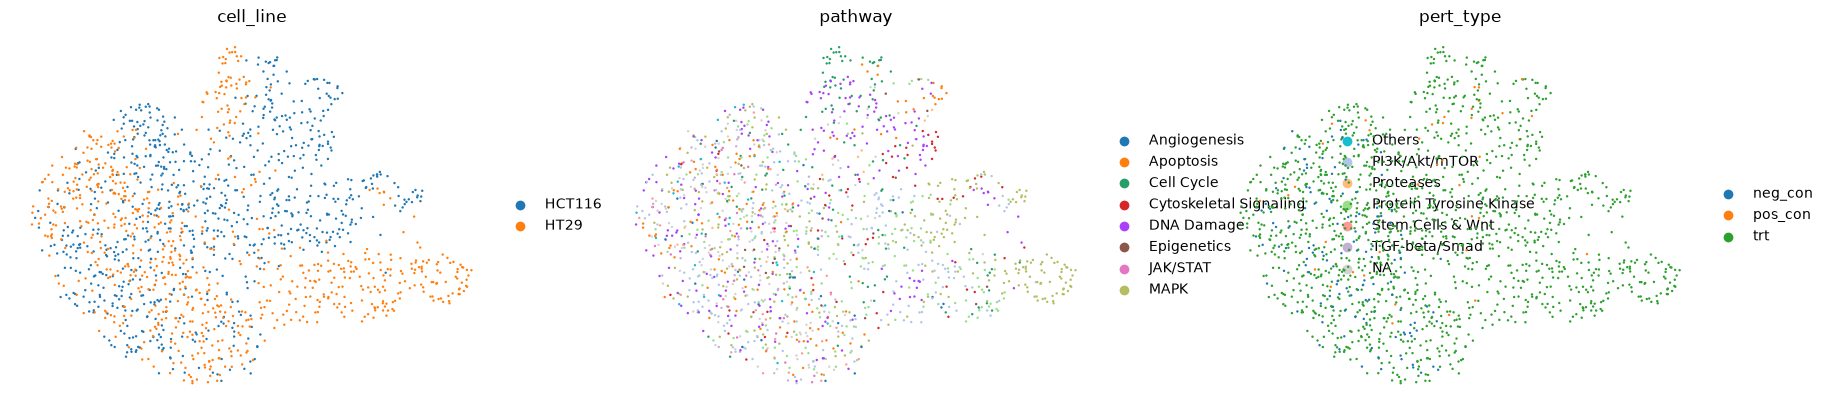

In [10]:
sc.pl.umap(adata, color=["cell_line", "pathway", "pert_type"], ncols=3, frameon=False, size=12)